In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
%config InlineBackend.figure_format = 'retina'

In [2]:
def plot(fun, a = -1, b = 1, c = -1, d = 1, trace = None):

    x1_ = np.linspace(a, b, 100)
    x2_ = np.linspace(c, d, 100)
    x1, x2 = np.meshgrid(x1_, x2_)
    y = fun(x1, x2)

    surface = go.Surface(x = x1, y = x2, z = y, opacity = 0.8, colorscale = 'balance', contours = dict(
            z = dict(show = True, usecolormap = True, width = 4, project_z = True)))

    fig = go.Figure(data=[surface])

    if trace is not None:
        y_trace = fun(trace[:, 0], trace[:, 1])
        fig.add_trace(go.Scatter3d(x = trace[:, 0],y = trace[:, 1], z = y_trace, mode = 'lines+markers',
                marker = dict(size = 4, color = 'red'), line = dict(width = 3, color = 'red'), name = 'Trace'))

    fig.update_layout(scene = dict(aspectratio = dict(x = 1, y = 1, z = 1), xaxis_title = 'x1', yaxis_title = 'x2', zaxis_title = 'y'),
                      width = 700, height = 500)

    fig.show()

In [3]:
def f(x1, x2):
    return x1 ** 2 + x2 ** 2

plot(f, -1, 1, -1, 1)

In [4]:
def func(x1, x2, c1 = 1, c2 = 1):
    return c1 * (x1 ** 2) + c2 * (x2 ** 2)

In [5]:
def grad_func(x1, x2, c1 = 1, c2 = 1):
    return np.array([2 * c1 * x1, 2 * c2 * x2])

In [6]:
grad_func(x1 = 0.5, x2 = 1.5, c1 = 2, c2 = 3)

array([2., 9.])

In [7]:
def gradient_descent(grad_func, step_size = 0.1, step_numbers = 50):

    x = np.random.rand(2) * 4 - 2
    trace = np.zeros((step_numbers + 1, 2))
    trace[0] = x

    for i in range(step_numbers):
        gradient = grad_func(x[0], x[1])
        x = x - step_size * gradient
        trace[i + 1] = x

    return trace

In [8]:
trace = gradient_descent(grad_func, 0.1, 100)
plot(func, trace = trace)

In [9]:
trace = gradient_descent(grad_func, 0.01, 100)
plot(func, trace = trace)

In [10]:
trace = gradient_descent(grad_func, 1, 100)
plot(func, trace = trace)

In [11]:
second_func = lambda x1, x2: func(x1, x2, 1, 5)
grad_second_func = lambda x1, x2: grad_func(x1, x2, 1, 5)

In [12]:
for i in [0.01, 0.1, 0.5]:
    trace = gradient_descent(grad_second_func, i, 100)
    plot(second_func, trace = trace)

In [13]:
np.random.seed(25)

In [14]:
def plot_gradient(w_list, title):
    A, B = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = np.mean(np.power(np.dot(X, w_tmp) - Y, 2))

    plt.figure(figsize = (12, 7))
    plt.title(title)
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim((w_list[:, 0].min() - 0.2, w_list[:, 0].max() + 0.2))
    plt.ylim((w_list[:, 1].min() - 0.2, w_list[:, 1].max() + 0.2))
    plt.gca().set_aspect("equal")

    CS = plt.contour(
        A, B, levels, levels = np.logspace(0, 1, num = 20), cmap = plt.cm.rainbow_r)

    CB = plt.colorbar(CS, shrink = 0.8, extend = "both")

    plt.scatter(w_true[0], w_true[1], c="r")
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])
    plt.show()

In [15]:
n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size = (n_features, ))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
Y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_0 = np.random.uniform(-2, 2, (n_features))

In [16]:
w = w_0.copy()
w_list = [w.copy()]
step_size = 1e-2

for i in range(num_steps):
    w = w - 2 * step_size * np.dot(X.T, np.dot(X, w) - Y) / Y.shape[0]
    w_list.append(w.copy())
w_list = np.array(w_list)

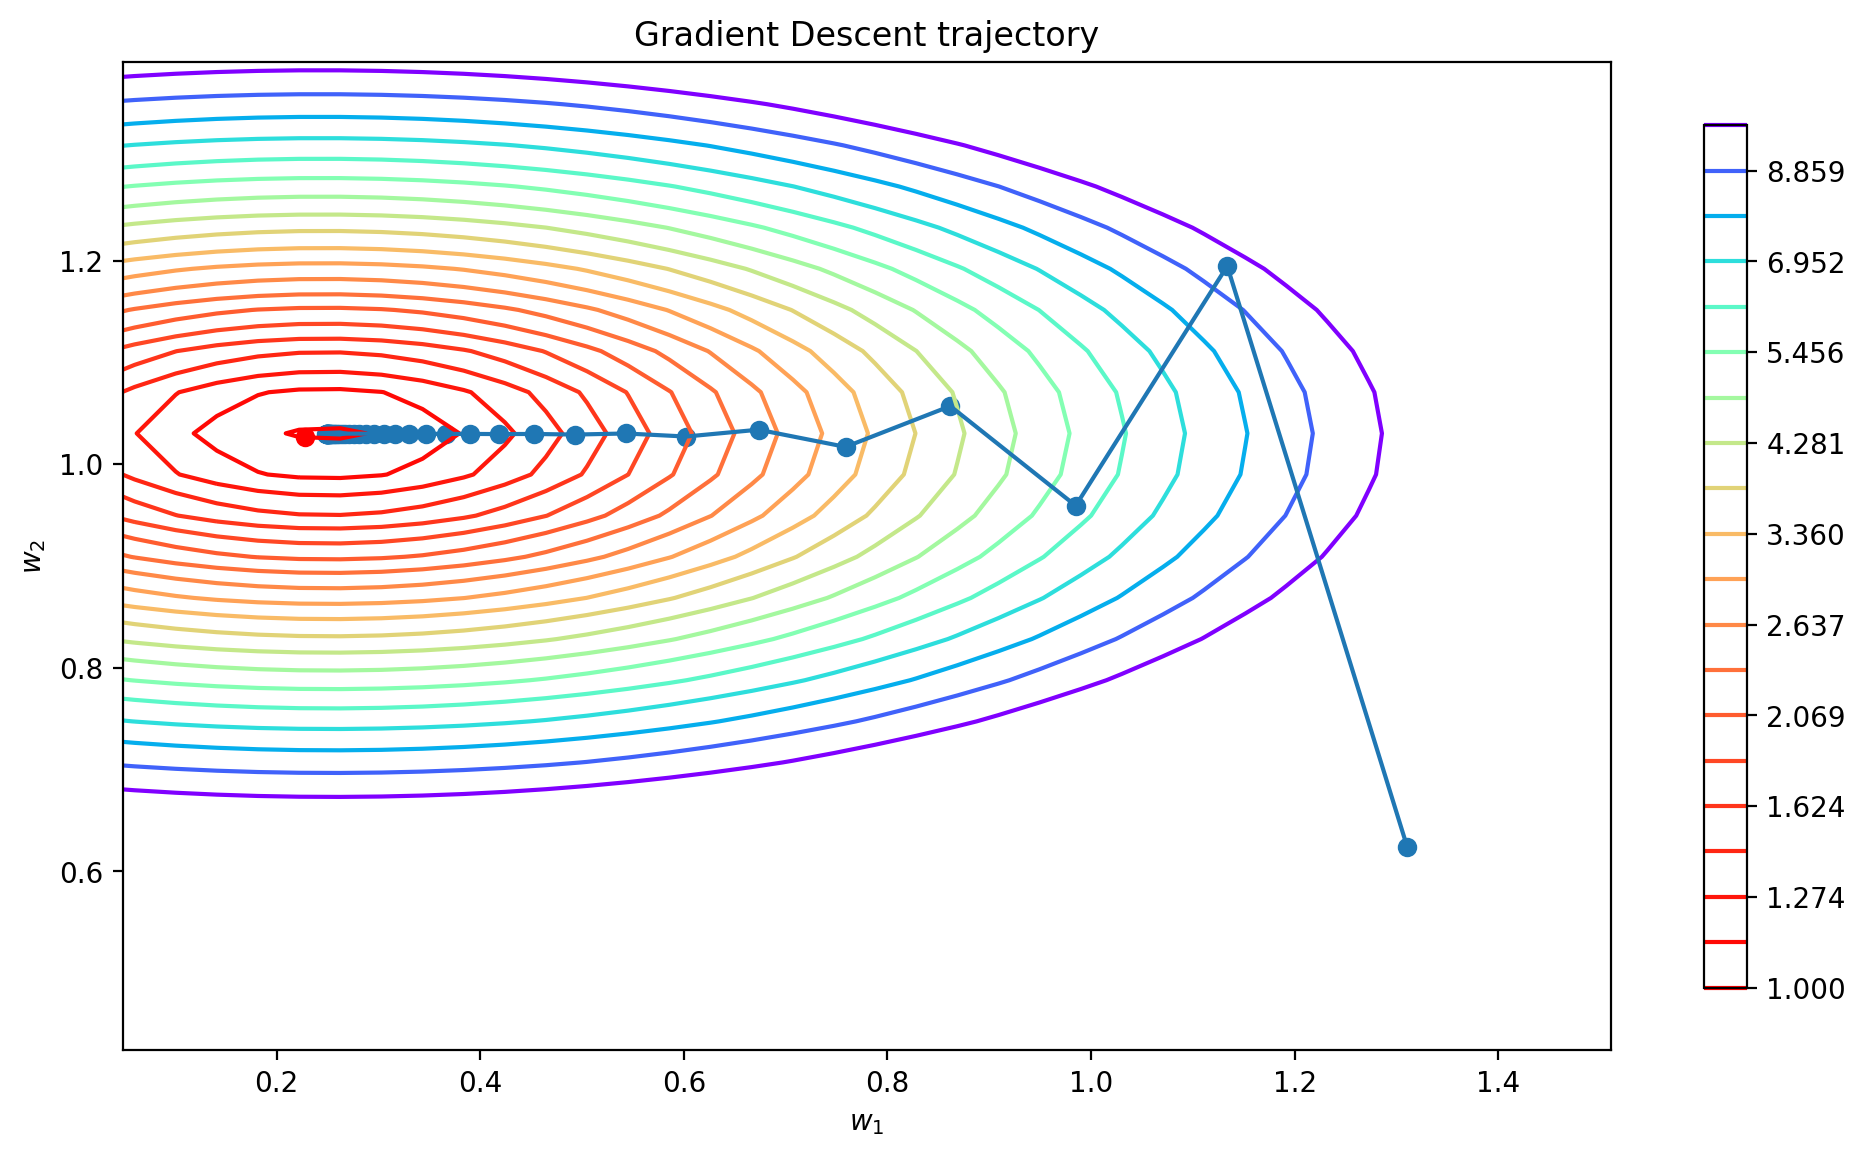

In [17]:
plot_gradient(w_list, 'Gradient Descent trajectory')

In [18]:
def calc_grad_on_batch(X, Y, w, batch_size):
    sample = np.random.randint(n_objects, size=batch_size)
    return 2 * np.dot(X[sample].T, np.dot(X[sample], w) - Y[sample]) / batch_size

In [19]:
step_size = 1e-2

w = w_0.copy()
w_list = [w.copy()]

for i in range(num_steps):
    w -= step_size * calc_grad_on_batch(X, Y, w, batch_size)
    w_list.append(w.copy())

w_list = np.array(w_list)

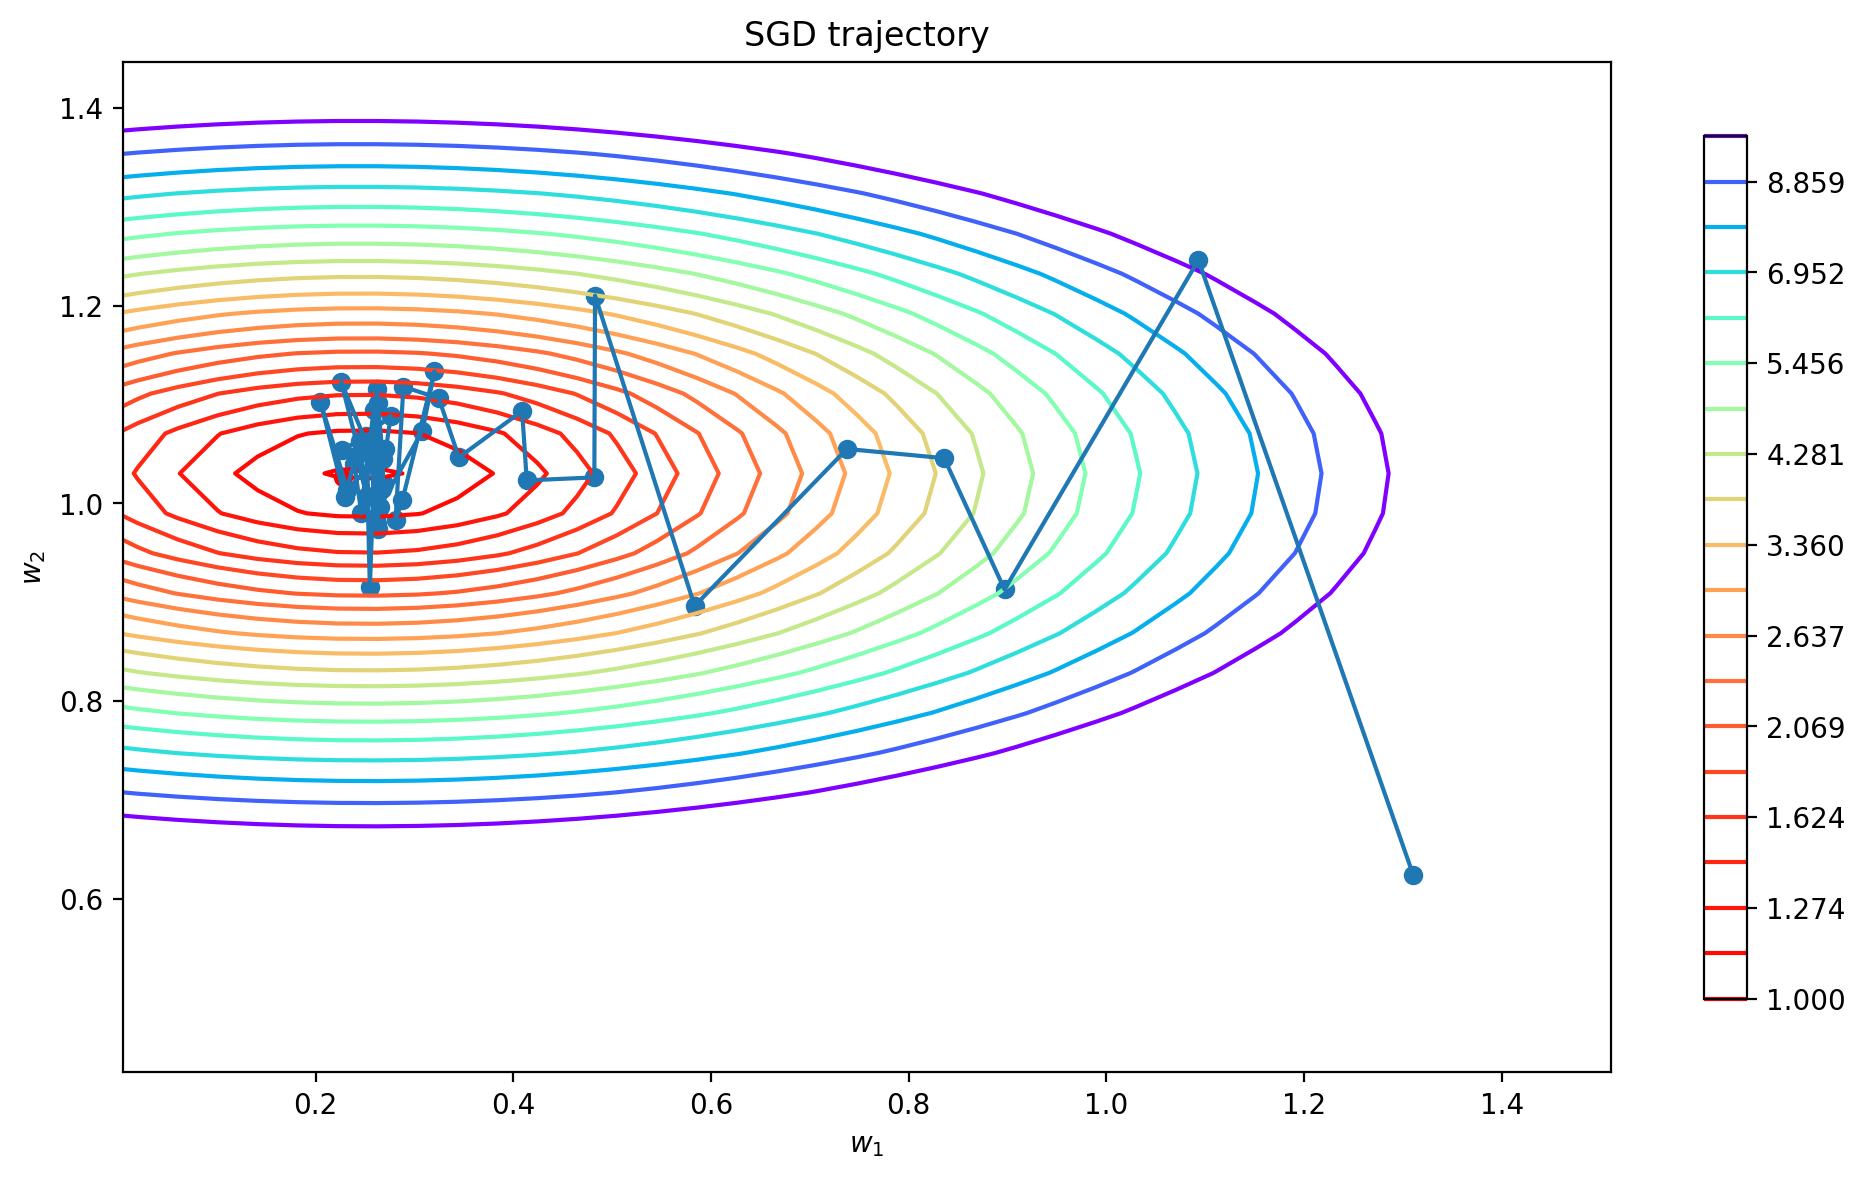

In [20]:
plot_gradient(w_list, "SGD trajectory")